# 1. Descarga del conjunto de datos

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadr
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [18]:
result = pyreadr.read_r('listings.RData')

In [19]:
df = result[list(result.keys())[0]]

In [20]:
df.shape

(171748, 80)

In [21]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171748 entries, 0 to 171747
Data columns (total 80 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   id                                            171748 non-null  float64
 1   listing_url                                   171748 non-null  object 
 2   scrape_id                                     171748 non-null  float64
 3   last_scraped                                  171748 non-null  object 
 4   source                                        171748 non-null  object 
 5   name                                          171748 non-null  object 
 6   description                                   171748 non-null  object 
 7   neighborhood_overview                         171748 non-null  object 
 8   picture_url                                   171748 non-null  object 
 9   host_id                                       17

In [23]:
df.describe()

,id,scrape_id,host_id,latitude,longitude,accommodates,bathrooms,minimum_nights,maximum_nights,minimum_nights_avg_ntm,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,1.717480e+05,1.717480e+05,1.717480e+05,171748.000000,171748.000000,171748.000000,140352.000000,171748.000000,1.717480e+05,171748.000000,...,131446.000000,131424.000000,131440.000000,131420.000000,131420.000000,171748.000000,171748.000000,171748.000000,171748.000000,131461.000000
mean,6.362915e+17,2.025107e+13,2.002571e+08,33.776320,-109.489530,4.106796,1.551795,16.996559,1.298827e+04,17.487677,...,4.752217,4.859050,4.852813,4.804140,4.690129,45.879987,39.608950,5.539005,0.082114,1.344455
std,5.834928e+17,1.419625e+08,2.048830e+08,7.236441,30.024424,2.836661,1.014407,30.014597,5.181840e+06,30.788964,...,0.411183,0.335401,0.358002,0.344275,0.428966,135.161293,131.065101,37.500862,1.643607,1.788745
min,6.000000e+00,2.025092e+13,2.300000e+01,18.989648,-159.716528,1.000000,0.000000,1.000000,1.000000e+00,0.700000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.599300e+07,2.025092e+13,2.633063e+07,30.381088,-118.591115,2.000000,1.000000,2.000000,9.000000e+01,2.000000,...,4.690000,4.860000,4.860000,4.750000,4.620000,1.000000,1.000000,0.000000,0.000000,0.190000
50%,7.249557e+17,2.025120e+13,1.080585e+08,34.089840,-117.865347,4.000000,1.000000,4.000000,3.650000e+02,4.400000,...,4.880000,4.960000,4.960000,4.910000,4.800000,3.000000,1.000000,0.000000,0.000000,0.700000
75%,1.182638e+18,2.025120e+13,3.765745e+08,40.702460,-73.997148,6.000000,2.000000,30.000000,1.125000e+03,30.000000,...,5.000000,5.000000,5.000000,5.000000,4.920000,21.000000,12.000000,1.000000,0.000000,2.000000
max,1.567804e+18,2.025120e+13,7.320923e+08,42.391844,-70.996000,16.000000,32.500000,1125.000000,2.147484e+09,1125.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,1189.000000,1189.000000,567.000000,60.000000,120.370000


In [24]:
df['price'].head

<bound method NDFrame.head of 0          $97.00
1         $160.00
2          $38.00
3         $145.00
4          $58.00
           ...   
171743        NaN
171744        NaN
171745        NaN
171746        NaN
171747        NaN
Name: price, Length: 171748, dtype: object>

Se verificó que todos los precios fueran en dólares antes de convertirlos de object a float

In [27]:
df['price'].str.extract(r'([^0-9.,])').value_counts()

0
$    76246
Name: count, dtype: int64

In [28]:
df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [29]:
df['price'].dtype

dtype('float64')

In [30]:
df.describe()

,id,scrape_id,host_id,latitude,longitude,accommodates,bathrooms,price,minimum_nights,maximum_nights,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,1.717480e+05,1.717480e+05,1.717480e+05,171748.000000,171748.000000,171748.000000,140352.000000,76246.000000,171748.000000,1.717480e+05,...,131446.000000,131424.000000,131440.000000,131420.000000,131420.000000,171748.000000,171748.000000,171748.000000,171748.000000,131461.000000
mean,6.362915e+17,2.025107e+13,2.002571e+08,33.776320,-109.489530,4.106796,1.551795,750.509220,16.996559,1.298827e+04,...,4.752217,4.859050,4.852813,4.804140,4.690129,45.879987,39.608950,5.539005,0.082114,1.344455
std,5.834928e+17,1.419625e+08,2.048830e+08,7.236441,30.024424,2.836661,1.014407,4250.606945,30.014597,5.181840e+06,...,0.411183,0.335401,0.358002,0.344275,0.428966,135.161293,131.065101,37.500862,1.643607,1.788745
min,6.000000e+00,2.025092e+13,2.300000e+01,18.989648,-159.716528,1.000000,0.000000,8.000000,1.000000,1.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.599300e+07,2.025092e+13,2.633063e+07,30.381088,-118.591115,2.000000,1.000000,120.000000,2.000000,9.000000e+01,...,4.690000,4.860000,4.860000,4.750000,4.620000,1.000000,1.000000,0.000000,0.000000,0.190000
50%,7.249557e+17,2.025120e+13,1.080585e+08,34.089840,-117.865347,4.000000,1.000000,193.000000,4.000000,3.650000e+02,...,4.880000,4.960000,4.960000,4.910000,4.800000,3.000000,1.000000,0.000000,0.000000,0.700000
75%,1.182638e+18,2.025120e+13,3.765745e+08,40.702460,-73.997148,6.000000,2.000000,326.000000,30.000000,1.125000e+03,...,5.000000,5.000000,5.000000,5.000000,4.920000,21.000000,12.000000,1.000000,0.000000,2.000000
max,1.567804e+18,2.025120e+13,7.320923e+08,42.391844,-70.996000,16.000000,32.500000,50123.000000,1125.000000,2.147484e+09,...,5.000000,5.000000,5.000000,5.000000,5.000000,1189.000000,1189.000000,567.000000,60.000000,120.370000


In [33]:
df.isnull().sum().sort_values(ascending=False).head(20)

calendar_updated                171748
price                            95502
estimated_revenue_l365d          95502
neighbourhood_group_cleansed     50683
review_scores_location           40328
review_scores_value              40328
review_scores_checkin            40324
review_scores_accuracy           40312
review_scores_communication      40308
review_scores_cleanliness        40302
review_scores_rating             40287
reviews_per_month                40287
beds                             31686
bathrooms                        31396
license                          10533
bedrooms                         10473
host_total_listings_count          876
host_listings_count                876
minimum_minimum_nights              71
minimum_maximum_nights              71
dtype: int64

In [34]:
df['price'].describe()

count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price, dtype: float64

In [40]:
df = df.dropna(subset=['price'])

In [41]:
df.shape

(76246, 80)

# 2. Análisis exploratorio extenso de los datos

In [43]:
df['price'] = df['price'].replace(r'[\$,]', '', regex=True)

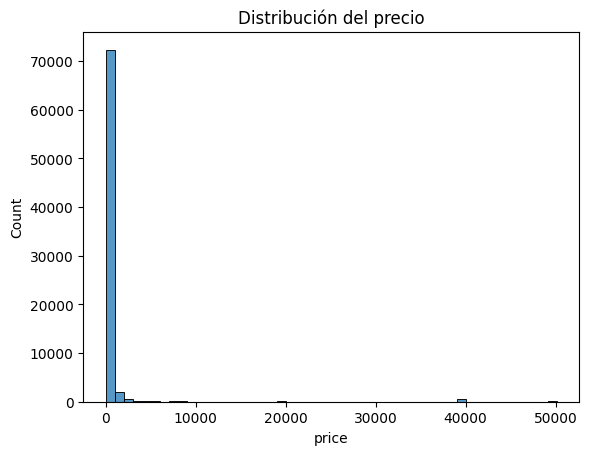

In [44]:
plt.figure()
sns.histplot(df['price'], bins=50)
plt.title('Distribución del precio')
plt.show()

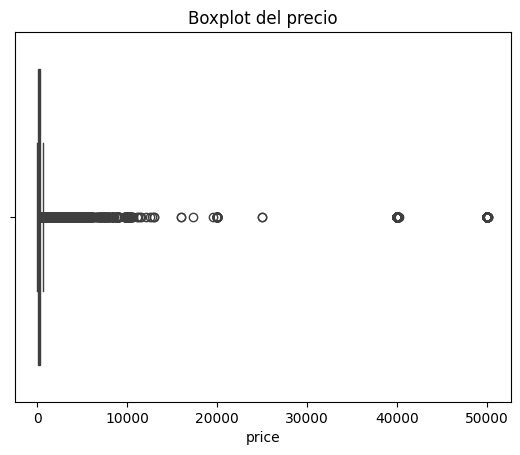

In [45]:
plt.figure()
sns.boxplot(x=df['price'])
plt.title('Boxplot del precio')
plt.show()

In [46]:
df['price'].quantile([0.25, 0.5, 0.75, 0.9, 0.95])

0.25     120.0
0.50     193.0
0.75     326.0
0.90     629.0
0.95    1034.0
Name: price, dtype: float64

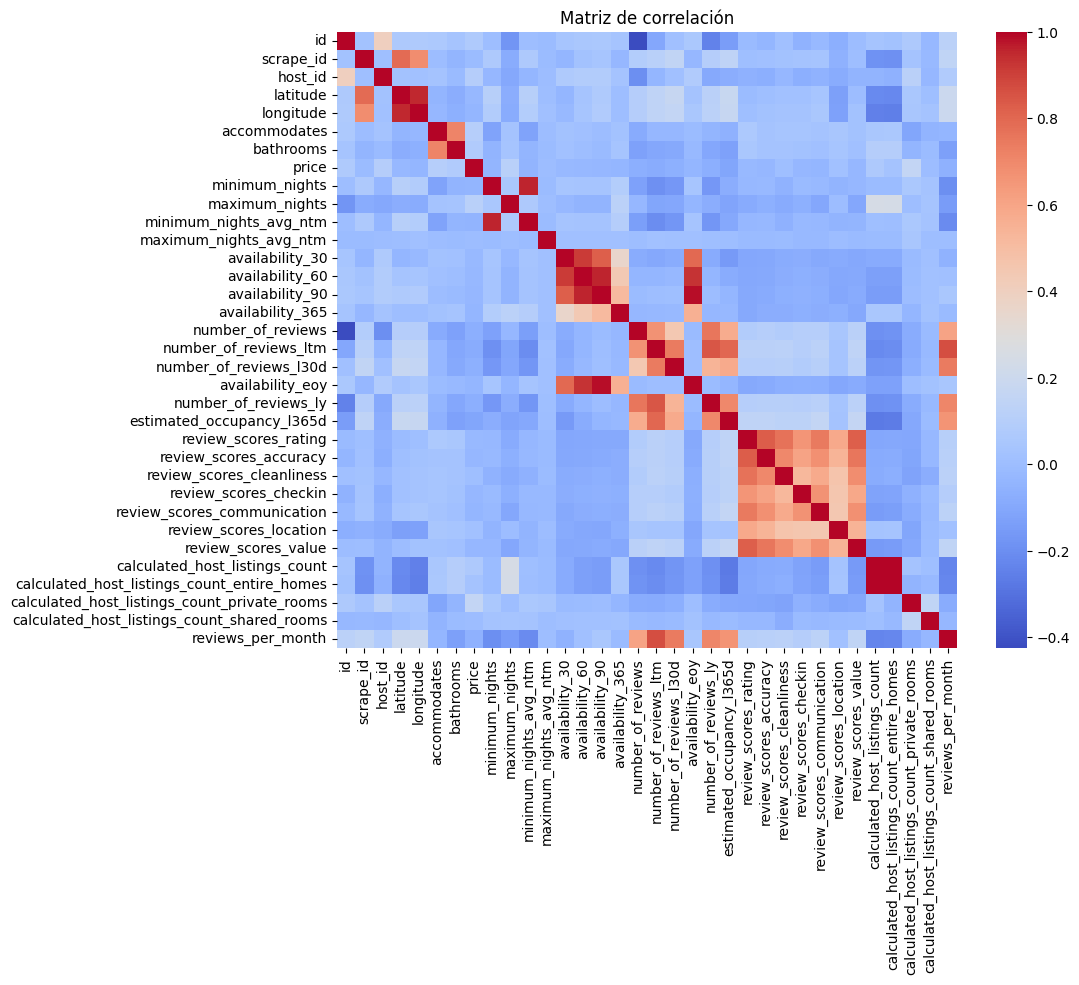

In [47]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

In [48]:
corr['price'].sort_values(ascending=False)

price                                           1.000000
calculated_host_listings_count_private_rooms    0.154335
maximum_nights                                  0.111292
accommodates                                    0.099671
host_id                                         0.095678
bathrooms                                       0.079704
id                                              0.073913
calculated_host_listings_count                  0.067503
calculated_host_listings_count_entire_homes     0.027066
review_scores_location                          0.017559
review_scores_cleanliness                       0.007770
maximum_nights_avg_ntm                         -0.003881
calculated_host_listings_count_shared_rooms    -0.006960
scrape_id                                      -0.011021
review_scores_rating                           -0.018521
availability_30                                -0.020832
availability_60                                -0.027714
latitude                       

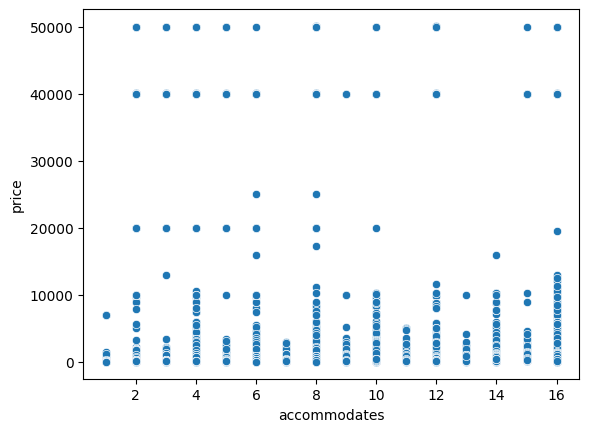

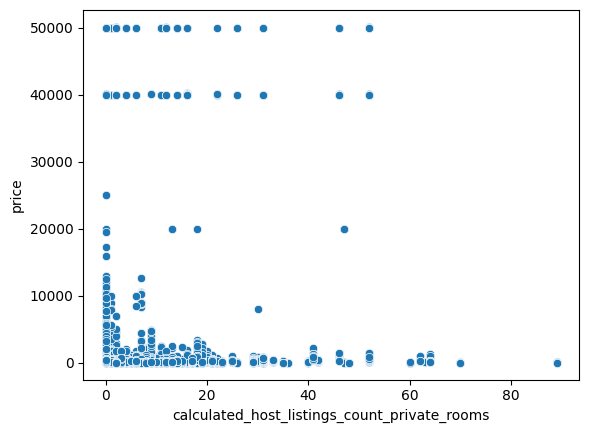

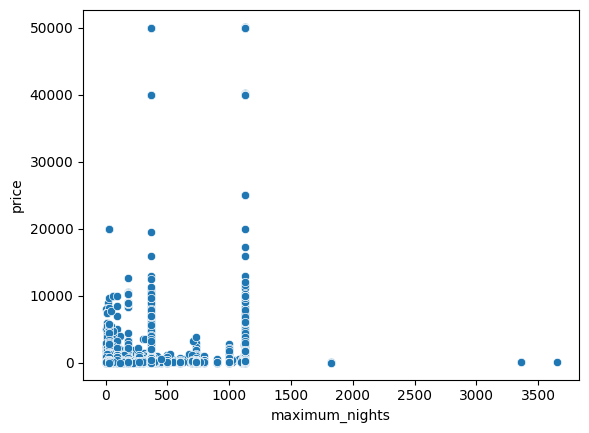

In [49]:
sns.scatterplot(x=df['accommodates'], y=df['price'])
plt.show()

sns.scatterplot(x=df['calculated_host_listings_count_private_rooms'], y=df['price'])
plt.show()

sns.scatterplot(x=df['maximum_nights'], y=df['price'])
plt.show()

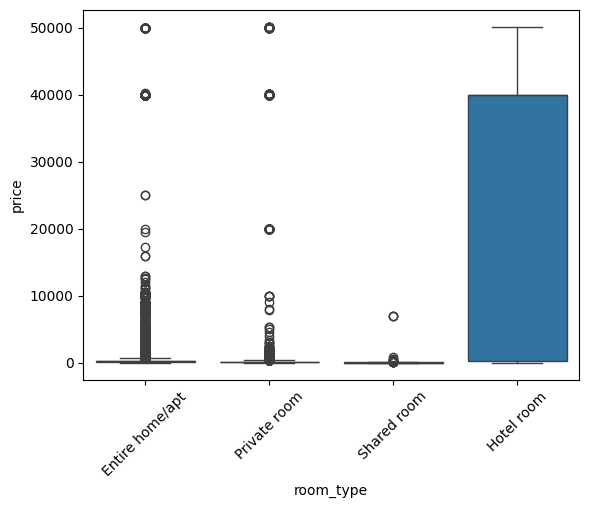

In [50]:
sns.boxplot(x='room_type', y='price', data=df)
plt.xticks(rotation=45)
plt.show()

# 3. Análisis de grupos en la EDA

In [55]:
y = df['price']

X = df.select_dtypes(include=['int64', 'float64']).copy()
X = X.drop(columns=['price'], errors='ignore')

cols_to_keep = [
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'availability_365',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating'
]

In [56]:
imputer = SimpleImputer(strategy='mean')
X_final = imputer.fit_transform(X)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [57]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y,
    test_size=0.3,
    random_state=42
)

In [58]:
# entrenar y evaluar el arbol con todas las variables
tree_full = DecisionTreeRegressor(random_state=42)
tree_full.fit(X_train_f, y_train_f)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [59]:
y_pred_f = tree_full.predict(X_test_f)

In [60]:
print("R2 (todas las variables):", r2_score(y_test_f, y_pred_f))
print("MSE (todas las variables):", mean_squared_error(y_test_f, y_pred_f))

R2 (todas las variables): 0.5030431268326037
MSE (todas las variables): 9028506.38808254


# ANALISIS DE GRUPOS

In [61]:
group_analysis = df.groupby('room_type')['price'].agg(['mean', 'median', 'count'])
group_analysis

,mean,median,count
room_type,,,
Entire home/apt,505.122921,205.0,65709
Hotel room,24477.200308,40000.0,649
Private room,838.869637,85.0,9673
Shared room,149.372093,42.0,215


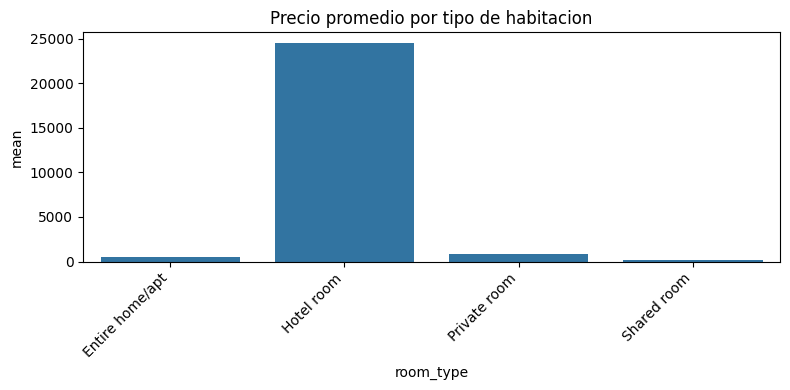

In [62]:
group_plot = group_analysis.reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=group_plot, x='room_type', y='mean')
plt.xticks(rotation=45, ha='right')
plt.title('Precio promedio por tipo de habitacion')
plt.tight_layout()
plt.show()

# 4. División en entrenamiento y prueba

In [63]:
print("Filas entrenamiento (X_train_f):", len(X_train_f))
print("Filas prueba (X_test_f):", len(X_test_f))
print("Shape X_train_f:", X_train_f.shape)
print("Shape X_test_f:", X_test_f.shape)

Filas entrenamiento (X_train_f): 53372
Filas prueba (X_test_f): 22874
Shape X_train_f: (53372, 15)
Shape X_test_f: (22874, 15)


In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [65]:
X_train.shape, X_test.shape

((53372, 15), (22874, 15))

# 5. Arbol de regresión

In [73]:
df_model = df[cols_to_keep].copy()

y = df_model['price']
X = df_model.drop(columns=['price'])

X_encoded = pd.get_dummies(X, drop_first=True)

# volver a dividir el dataset con las variables codificadas
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.3,
    random_state=42
)

# entrenar un modelo de regresión

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=True)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [74]:
# predecir en el conjunto de prueba

y_pred = tree.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=True)


# 6. Presición y análisis del resultado

In [75]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 12431076.349553581
R2: 0.3157551684369653


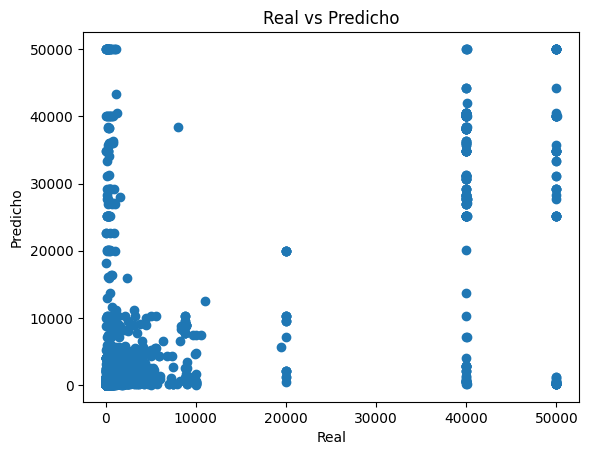

In [76]:
plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Real vs Predicho")
plt.show()

# 7. Modelos adicionales con distinta profundidad

In [77]:
depths = [3, 5, 7, 10, 15, 20]

train_scores = []
test_scores = []

for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, c

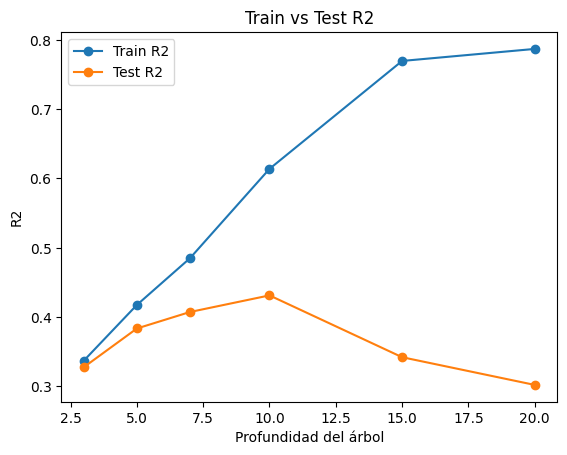

In [78]:
plt.plot(depths, train_scores, marker='o', label='Train R2')
plt.plot(depths, test_scores, marker='o', label='Test R2')

plt.xlabel('Profundidad del árbol')
plt.ylabel('R2')
plt.title('Train vs Test R2')
plt.legend()
plt.show()

In [79]:
best_tree = DecisionTreeRegressor(max_depth=10, random_state=42)
best_tree.fit(X_train, y_train)

y_pred_best = best_tree.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=True)


In [80]:
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("MSE (mejor modelo):", mse_best)
print("R2 (mejor modelo):", r2_best)

MSE (mejor modelo): 10330247.523136364
R2 (mejor modelo): 0.43139127476063355


# 8. Regresión lineal y comparación con el mejor árbol

In [81]:
imputer = SimpleImputer(strategy='mean')

In [82]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [83]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [84]:
y_pred_lr = lr.predict(X_test)

In [85]:
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

In [86]:
print("Árbol de regresión:")
print("R2:", r2_best)
print("MSE:", mse_best)

print("\nRegresión lineal:")
print("R2:", r2_lr)
print("MSE:", mse_lr)

Árbol de regresión:
R2: 0.43139127476063355
MSE: 10330247.523136364

Regresión lineal:
R2: 0.3454370822661629
MSE: 11891827.647932025


# 9. Creación de variable de respuesta categórica

In [87]:
q33 = df['price'].quantile(0.33)
q66 = df['price'].quantile(0.66)
print("P33:", q33, "| P66:", q66)
print("Límites elegidos: Económico <= 120 < Intermedio <= 326 < Caro")

P33: 141.0 | P66: 264.0
Límites elegidos: Económico <= 120 < Intermedio <= 326 < Caro


In [88]:
def categorize_price(price):
    if price <= 120:
        return 'Economico'
    elif price <= 326:
        return 'Intermedio'
    else:
        return 'Caro'

# crear variable categórica sobre TODO el df
df['price_category'] = df['price'].apply(categorize_price)

In [89]:
df['price_category'].value_counts()

price_category
Intermedio    37882
Economico     19310
Caro          19054
Name: count, dtype: int64

In [90]:
y_class = df['price_category']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_final, y_class,
    test_size=0.3,
    random_state=42,
    stratify=y_class
)

# 10. Arbol de clasificación

In [91]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_c, y_train_c)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

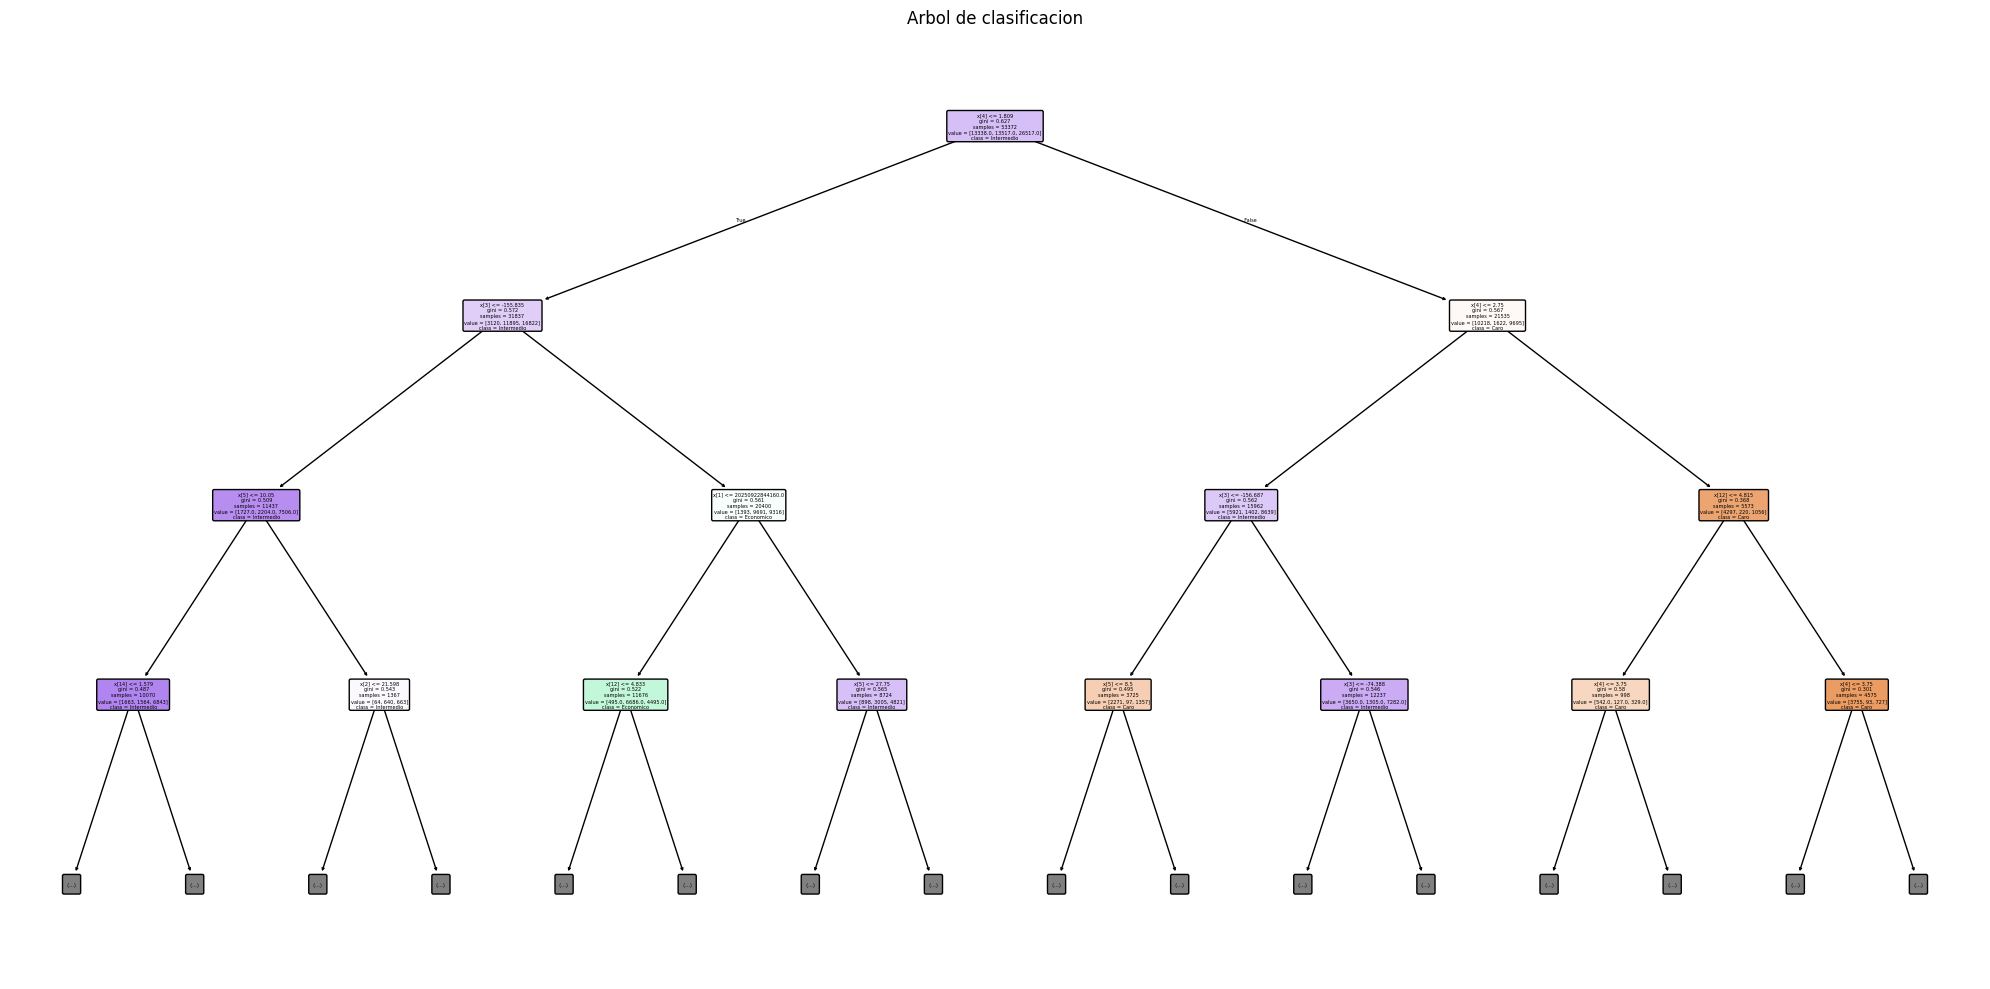

In [92]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(clf, filled=True, rounded=True, class_names=clf.classes_, ax=ax, max_depth=3)
ax.set_title('Arbol de clasificacion')
plt.tight_layout()
plt.show()

In [93]:
y_pred_c = clf.predict(X_test_c)

# 11. Eficiencia algoritmo de clasifiación

In [94]:
accuracy = accuracy_score(y_test_c, y_pred_c)
print("Accuracy:", accuracy)

Accuracy: 0.6678324735507564


# 12. Matriz de confusión y análisis de errores

In [95]:
cm = confusion_matrix(y_test_c, y_pred_c)
print(classification_report(y_test_c, y_pred_c, target_names=clf.classes_))
cm

              precision    recall  f1-score   support

        Caro       0.68      0.68      0.68      5716
   Economico       0.62      0.62      0.62      5793
  Intermedio       0.69      0.68      0.68     11365

    accuracy                           0.67     22874
   macro avg       0.66      0.66      0.66     22874
weighted avg       0.67      0.67      0.67     22874



array([[3909,  226, 1581],
       [ 230, 3603, 1960],
       [1593, 2008, 7764]])

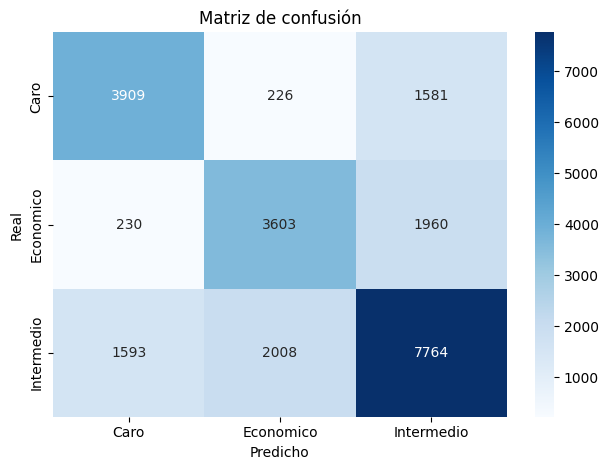

In [96]:
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=clf.classes_, yticklabels=clf.classes_
)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

# 13. Validación cruzada

In [97]:
# Modelo base
tree_cv = DecisionTreeClassifier(max_depth=10, random_state=42)

scores = cross_val_score(
    tree_cv,
    X_train_c,
    y_train_c,
    cv=5,
    scoring='accuracy'
)

print("Accuracy por fold:", scores)
print("Accuracy promedio:", scores.mean())

Accuracy por fold: [0.69039813 0.69667447 0.69205546 0.69814503 0.68409219]
Accuracy promedio: 0.6922730546636775


# 14. Modelos adicionales cambiando la profundidad

In [98]:
depths = [3, 5, 10, 15, 20]

train_acc = []
test_acc = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train_c, y_train_c)
    
    # Predicciones
    y_train_pred = model.predict(X_train_c)
    y_test_pred = model.predict(X_test_c)
    
    # Accuracy
    acc_train = accuracy_score(y_train_c, y_train_pred)
    acc_test = accuracy_score(y_test_c, y_test_pred)
    
    train_acc.append(acc_train)
    test_acc.append(acc_test)
    
    print(f"Depth {d} → Train: {acc_train:.4f} | Test: {acc_test:.4f}")

Depth 3 → Train: 0.6157 | Test: 0.6128
Depth 5 → Train: 0.6522 | Test: 0.6420
Depth 10 → Train: 0.7396 | Test: 0.6958
Depth 15 → Train: 0.8702 | Test: 0.6905
Depth 20 → Train: 0.9662 | Test: 0.6792


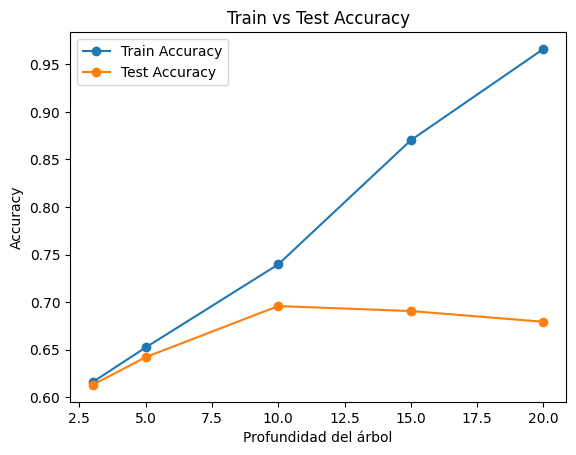

In [99]:
plt.plot(depths, train_acc, marker='o', label='Train Accuracy')
plt.plot(depths, test_acc, marker='o', label='Test Accuracy')

plt.xlabel('Profundidad del árbol')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy')
plt.legend()
plt.show()

# 15. Random forest y comparación

In [100]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

#predicciones
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

#métricas
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

r2_train_rf = r2_score(y_train, y_train_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)

print("Random Forest:")
print("RMSE Train:", rmse_train_rf)
print("RMSE Test:", rmse_test_rf)
print("R2 Train:", r2_train_rf)
print("R2 Test:", r2_test_rf)

Random Forest:
RMSE Train: 2080.8729876826555
RMSE Test: 2974.3742658540236
R2 Train: 0.7597690122528273
R2 Test: 0.5130391781305998


In [101]:
gap_rf = rmse_test_rf - rmse_train_rf
porcentaje = gap_rf/rmse_train_rf * 100
print("Gap RF:", gap_rf)
print("Gap como porcentaje:", porcentaje)

Gap RF: 893.5012781713681
Gap como porcentaje: 42.93877057659378


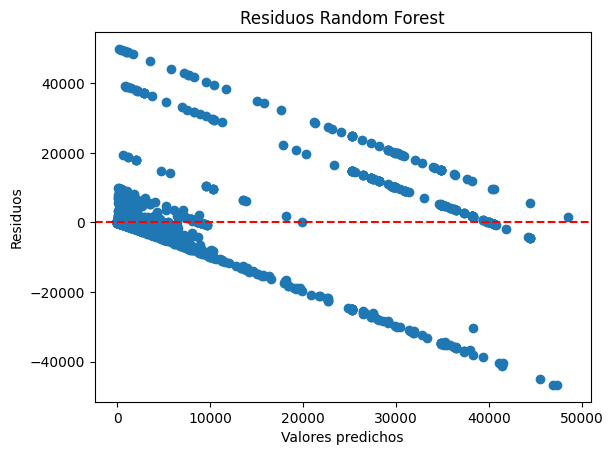

In [102]:
residuos_rf = y_test - y_test_pred_rf

plt.scatter(y_test_pred_rf, residuos_rf)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos Random Forest")
plt.show()

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10, 
    random_state=42
)

rf.fit(X_train, y_train)

# Predicciones
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

# Métricas
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

r2_train_rf = r2_score(y_train, y_train_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)

print("Random Forest (max_depth=10):")
print("RMSE Train:", rmse_train_rf)
print("RMSE Test:", rmse_test_rf)
print("R2 Train:", r2_train_rf)
print("R2 Test:", r2_test_rf)

Random Forest (max_depth=10):
RMSE Train: 2457.9843862820508
RMSE Test: 2961.4915170243867
R2 Train: 0.664806088481886
R2 Test: 0.5172483378327456


In [104]:
gap_rf = rmse_test_rf - rmse_train_rf
porcentaje = gap_rf/rmse_train_rf * 100
print("Gap RF:", gap_rf)
print("Gap como porcentaje:", porcentaje)

Gap RF: 503.5071307423359
Gap como porcentaje: 20.48455366732175


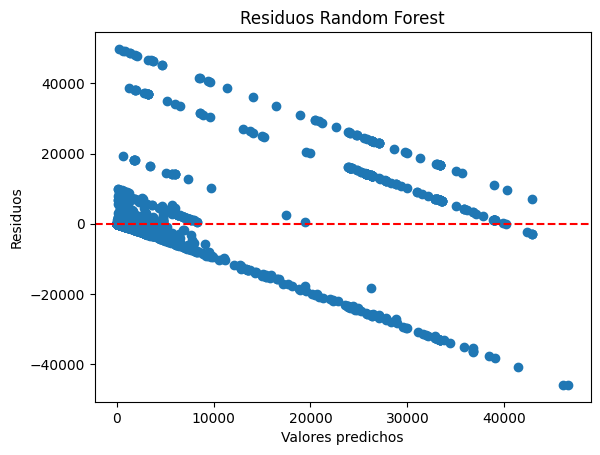

In [105]:
residuos_rf = y_test - y_test_pred_rf

plt.scatter(y_test_pred_rf, residuos_rf)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos Random Forest")
plt.show()

# 15. 1 Random forest sin outliers

In [106]:
df = df[df['price'] < df['price'].quantile(0.99)]

In [109]:
df_model = df[cols_to_keep].copy()

y = df_model['price']
X = df_model.drop(columns=['price'])

In [110]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [111]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.3,
    random_state=42
)

In [112]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=True)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [113]:
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))

r2_train_rf = r2_score(y_train, y_train_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)

print("Random Forest (sin outliers):")
print("RMSE Train:", rmse_train_rf)
print("RMSE Test:", rmse_test_rf)
print("R2 Train:", r2_train_rf)
print("R2 Test:", r2_test_rf)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=True)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/dtypes/astype.py:133: RuntimeWarning: invalid value encountered in cast
  return arr.astype(dtype, copy=True)


Random Forest (sin outliers):
RMSE Train: 391.9898304792491
RMSE Test: 489.32941991004327
R2 Train: 0.6539741570482651
R2 Test: 0.500876739930799


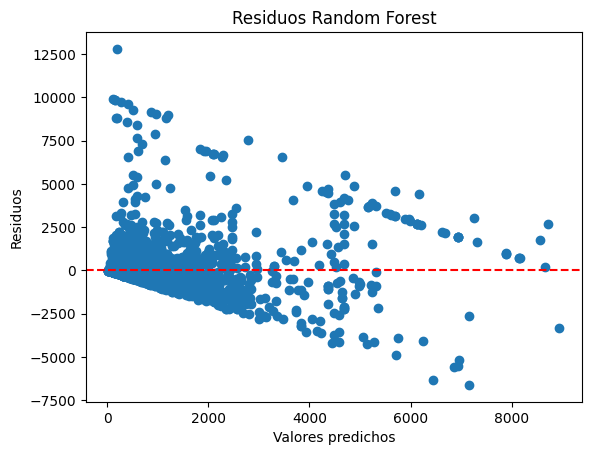

In [114]:
residuos_rf = y_test - y_test_pred_rf

plt.scatter(y_test_pred_rf, residuos_rf)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos Random Forest")
plt.show()